# Hands‑On Data Cleaning Notebook

*Generated: 2025-11-06 11:15*

This notebook guides you through a rigorous cleaning pass for your **capstone dataset**. Fill the TODOs and run cells in order. Keep this under version control (commits with meaningful messages).

## 1. DataSet Configuration
- Make sure your csv file(s) are in `data/`.
- Update `dataset_path` below.
- Modify/Update configurations here to set the base

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = "../data/gini_index.csv"
dataset_maxrows = 200

df = pd.read_csv(dataset_path)
#df.options.max(dataset_maxrows)  -- example of configuration


print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2582 entries, 0 to 2581
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Entity                           2582 non-null   object 
 1   Code                             2458 non-null   object 
 2   Year                             2582 non-null   int64  
 3   Gini coefficient (2021 prices)   2361 non-null   float64
 4   World regions according to OWID  272 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 101.0+ KB
None


## 2) DataSet Analysis 
- Updating existing column names from raw dataset for uniformity across datasets
- Performing head(), info() operations to get an overview of data
- Convert column types wherever needed
- Converting all string to small case for efficient data operations

In [3]:
df.columns = ["country_name","country_code","year","gini_index","world_regions"]

df["country_name"] = df["country_name"].astype("string")
df["country_code"] = df["country_code"].astype("string")

df["country_name"] = df["country_name"].str.lower()
df["country_code"] = df["country_code"].str.lower()
df["gini_index"] = df["gini_index"].round(2)

#print(df.head())           #shows first 5 records with header
#print(df.info())            #gives information about the column names along with their datatypes
print(df)                   #shows first 5 and last 5 data from datasets



       country_name country_code  year  gini_index world_regions
0       afghanistan          afg  2023         NaN          Asia
1     aland islands          ala  2023         NaN        Europe
2           albania          alb  1996        0.27           NaN
3           albania          alb  2002        0.32           NaN
4           albania          alb  2005        0.31           NaN
...             ...          ...   ...         ...           ...
2577         zambia          zmb  2023         NaN        Africa
2578       zimbabwe          zwe  2011        0.43           NaN
2579       zimbabwe          zwe  2017        0.44           NaN
2580       zimbabwe          zwe  2019        0.50           NaN
2581       zimbabwe          zwe  2023         NaN        Africa

[2582 rows x 5 columns]


## 3) Missing Data: Identify → Decide → Apply
- Find empty records

In [4]:
# Identify missing data
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
print(missing_report)

# show the missing rows

bool_series = pd.isnull(df["country_code"])
missing_country_code_data = df[bool_series]
#print(missing_country_code_data)

unique_countries = df['country_name'].unique()
unique_country_code = df['country_code'].unique()

#print(unique_countries)
#print(unique_country_code)

print(missing_country_code_data)
print(missing_country_code_data["country_name"].unique())



               missing_count  missing_pct
world_regions           2310        89.47
gini_index               221         8.56
country_code             124         4.80
country_name               0         0.00
year                       0         0.00
           country_name country_code  year  gini_index world_regions
28    argentina (urban)         <NA>  1980        0.41           NaN
29    argentina (urban)         <NA>  1986        0.43           NaN
30    argentina (urban)         <NA>  1987        0.45           NaN
31    argentina (urban)         <NA>  1991        0.47           NaN
32    argentina (urban)         <NA>  1992        0.45           NaN
...                 ...          ...   ...         ...           ...
2516    uruguay (urban)         <NA>  2001        0.45           NaN
2517    uruguay (urban)         <NA>  2002        0.46           NaN
2518    uruguay (urban)         <NA>  2003        0.45           NaN
2519    uruguay (urban)         <NA>  2004        0.46    

## 4) Remove inconsitent data
- remove data that has empty country code

In [15]:
df = df.dropna(subset=["country_code"])

#print(df)

missing_counts_1 = df.isnull().sum().sort_values(ascending=False)
missing_pct_1 = (missing_counts_1 / len(df) * 100).round(2)
missing_report_1 = pd.DataFrame({"missing_count": missing_counts_1, "missing_pct": missing_pct_1})
#print(missing_report_1)

unique_countries_1 = df['country_name'].unique()
unique_country_code_1 = df['country_code'].unique()

#print(unique_countries_1)
#print(unique_country_code_1)

missing_homicide_data = df[df['gini_index'].isna()]
print(missing_homicide_data.to_string())


                                      country_name country_code  year  gini_index  world_regions  zscore
0                                      afghanistan          afg  2023         NaN           Asia     NaN
1                                    aland islands          ala  2023         NaN         Europe     NaN
14                                         albania          alb  2023         NaN         Europe     NaN
18                                         algeria          dza  2023         NaN         Africa     NaN
19                                  american samoa          asm  2023         NaN        Oceania     NaN
20                                         andorra          and  2023         NaN         Europe     NaN
24                                          angola          ago  2023         NaN         Africa     NaN
25                                        anguilla          aia  2023         NaN  North America     NaN
26                             antigua and barbuda     

## 5) Remove Duplicate Records

In [6]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows detected.")


Duplicate rows found: 0
No duplicate rows detected.


## 6) Detect Outliers with Visualizations

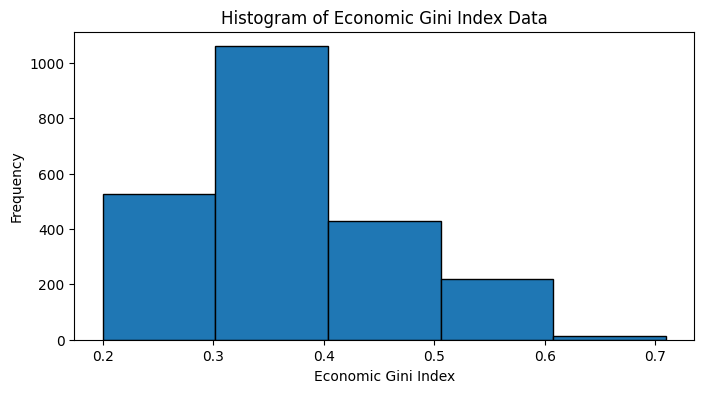

In [12]:
# HISTOGRAMS (one plot per numeric column)
plt.figure(figsize=(8, 4))
plt.hist(df["gini_index"], bins=5, edgecolor="black")
plt.title("Histogram of Economic Gini Index Data")
plt.xlabel("Economic Gini Index")
plt.ylabel("Frequency")
plt.show()


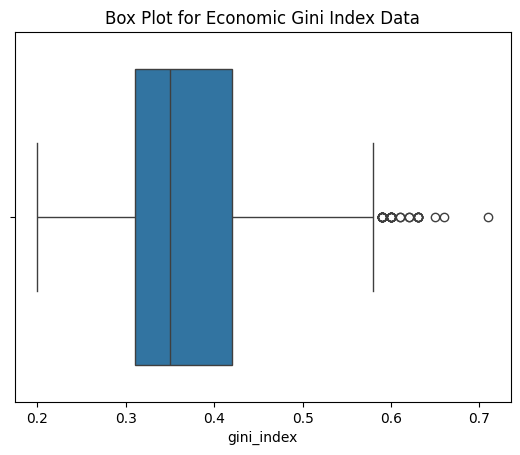

In [13]:
# BOX PLOTS (one plot per numeric column)
sns.boxplot(x=df['gini_index'])
plt.title("Box Plot for Economic Gini Index Data")
plt.show()


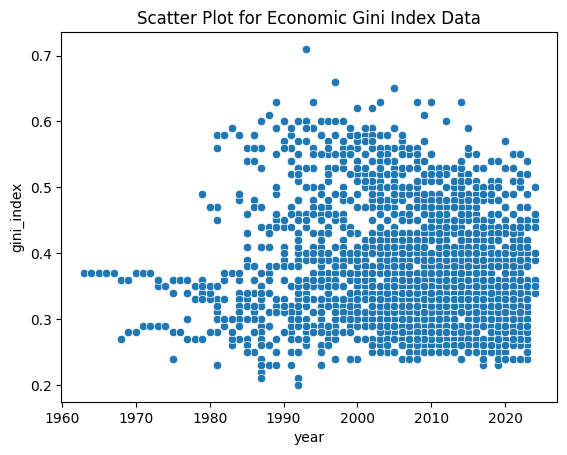

In [14]:
# Scatter Plot
sns.scatterplot(x=df['year'], y=df['gini_index'])
plt.title("Scatter Plot for Economic Gini Index Data")
plt.show()

In [15]:

# Calculate Q1, Q3, and IQR
Q1 = df["gini_index"].quantile(0.25)
Q3 = df["gini_index"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df["gini_index"] < lower_bound) | (df["gini_index"] > upper_bound)]

print("Outliers:")
print(outliers)

print("Outliers Total:",outliers.count())

Outliers:
                  country_name country_code  year  gini_index world_regions
223                    bolivia          bol  2000        0.62           NaN
225                    bolivia          bol  2002        0.59           NaN
227                    bolivia          bol  2005        0.59           NaN
254                   botswana          bwa  1993        0.60           NaN
255                   botswana          bwa  2002        0.62           NaN
261                     brazil          bra  1983        0.59           NaN
265                     brazil          bra  1987        0.60           NaN
266                     brazil          bra  1988        0.61           NaN
267                     brazil          bra  1989        0.63           NaN
268                     brazil          bra  1990        0.60           NaN
270                     brazil          bra  1993        0.60           NaN
271                     brazil          bra  1995        0.60           NaN
27

In [18]:
# Compute z-scores
df["zscore"] = (df["gini_index"] - df["gini_index"].mean()) / df["gini_index"].std()

# Mark values beyond ±3 standard deviations
outliers_z = df[df["zscore"].abs() > 3]

print("Outliers (Z-score):")
print(outliers_z)

Outliers (Z-score):
      country_name country_code  year  gini_index world_regions    zscore
1477        malawi          mwi  1997        0.66           NaN  3.306159
1638       namibia          nam  1993        0.71           NaN  3.880948
2090  south africa          zaf  2005        0.65           NaN  3.191201


C:\Users\Admin\AppData\Local\Temp\ipykernel_31520\2466463567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["zscore"] = (df["gini_index"] - df["gini_index"].mean()) / df["gini_index"].std()


## 7) Save Outputs

In [17]:
# Save cleaned dataset (CSV). Keep raw file untouched.
clean_path = "../data/gini_index_data_clean.csv"
df.to_csv(clean_path, index=False)
print("Saved cleaned file to:", clean_path)

# Optional: Save a small data dictionary (columns and inferred types)
data_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null": df.notnull().sum(),
    "unique": df.nunique()
})
data_dict_path = "../data/gini_index_data_dictionary.csv"
data_dict.to_csv(data_dict_path, index=False)
print("Saved data dictionary to:", data_dict_path)


Saved cleaned file to: ../data/gini_index_data_clean.csv
Saved data dictionary to: ../data/gini_index_data_dictionary.csv
